In [1]:
# Assingment-08
# Assingment No 03

In [2]:
# Task-1

In [3]:
# Task-2

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [5]:
df = pd.read_csv("employee_data.csv")
df

,Experience_Years,Salary,Overtime_Hours
0,0.7,29028,6
1,3.7,42600,22
2,3.5,50993,29
3,0.3,29358,3
4,8.2,94619,5
...,...,...,...
85,11.6,70947,5
86,6.7,51269,17
87,1.0,25737,7
88,4.1,47641,26


In [6]:
df.shape

(90, 3)

In [7]:
df.describe

<bound method NDFrame.describe of     Experience_Years  Salary  Overtime_Hours
0                0.7   29028               6
1                3.7   42600              22
2                3.5   50993              29
3                0.3   29358               3
4                8.2   94619               5
..               ...     ...             ...
85              11.6   70947               5
86               6.7   51269              17
87               1.0   25737               7
88               4.1   47641              26
89               2.7   23517               0

[90 rows x 3 columns]>

In [8]:
df.info

<bound method DataFrame.info of     Experience_Years  Salary  Overtime_Hours
0                0.7   29028               6
1                3.7   42600              22
2                3.5   50993              29
3                0.3   29358               3
4                8.2   94619               5
..               ...     ...             ...
85              11.6   70947               5
86               6.7   51269              17
87               1.0   25737               7
88               4.1   47641              26
89               2.7   23517               0

[90 rows x 3 columns]>

In [9]:
# Task=03

In [10]:
X = df[["Experience_Years", "Salary", "Overtime_Hours"]]
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
kmeans.fit(X)   

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [12]:
# Task-04

In [11]:
df["Cluster"] = kmeans.predict(X)
print(df.head(10))
print(df["Cluster"].value_counts().sort_index())

   Experience_Years  Salary  Overtime_Hours  Cluster
0               0.7   29028               6        0
1               3.7   42600              22        1
2               3.5   50993              29        1
3               0.3   29358               3        0
4               8.2   94619               5        2
5               4.1   35134              19        0
6               3.3   41814              27        1
7               9.8   82562               7        2
8              13.7   82906               5        2
9               0.1   30948               1        0
Cluster
0    32
1    31
2    27
Name: count, dtype: int64


In [13]:
# Task-05

In [14]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Experience_Years", "Salary", "Overtime_Hours"]
)
centers.index.name = "Cluster"
print(centers.round(2))

         Experience_Years    Salary  Overtime_Hours
Cluster                                            
0                    1.69  27277.66            4.59
1                    5.17  48532.87           20.71
2                   11.73  77567.85            5.85


In [15]:
# Task-06

Text(0.5, 1.0, 'Employee Segments (Salary vs Overtime Hours)')

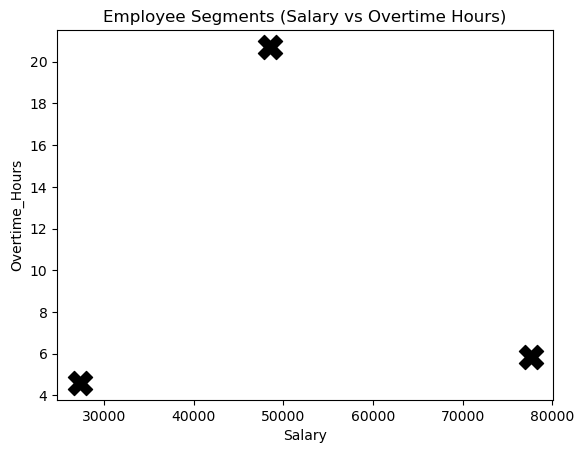

In [16]:
plt.scatter(
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=300, c="black", marker="X", label="Centroids"
)
plt.xlabel("Salary")
plt.ylabel("Overtime_Hours")
plt.title("Employee Segments (Salary vs Overtime Hours)")

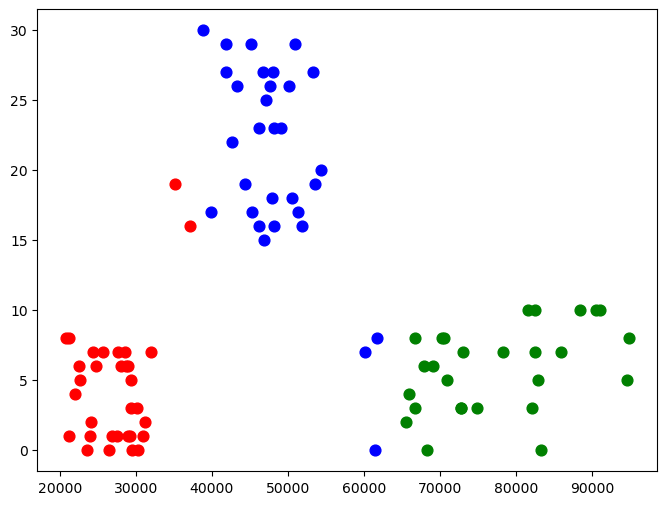

In [17]:
colors = ["red", "blue", "green"]
plt.figure(figsize=(8, 6))
for cluster_num in range(3):
    cluster_data = df[df["Cluster"] == cluster_num]
    plt.scatter(
        cluster_data["Salary"],            # x-axis
        cluster_data["Overtime_Hours"],    # y-axis
        s=60,
        color=colors[cluster_num],
        label=f"Cluster {cluster_num}"
    )